In [1]:
#run this cell first to install dependencies
#you may need to restart if any requirements are installed
import sys
import subprocess
import pkg_resources

def install_if_missing():
    with open("requirements.txt") as f:
        packages = [line.strip() for line in f if line.strip()]

    installed = {pkg.key for pkg in pkg_resources.working_set}

    missing = []
    for pkg in packages:
        pkg_name = pkg.split("==")[0].lower()
        if pkg_name not in installed:
            missing.append(pkg)

    if missing:
        print("Installing missing packages:", missing)
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    else:
        print("All requirements already installed.")

install_if_missing()

All requirements already installed.


C:\Users\bigfe\AppData\Local\Temp\ipykernel_22284\927862197.py:4: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Start: (42.501847, -83.3671729)
End: (42.5051809, -83.3590401)
Path length: 5
Path as node ID's is as follows: [61992598, 61950983, 61950972, 62259920, 62314213, 62167017]
Path as road names is as follows: ['Red Clover Road', 'Brandywine Road', 'Kendallwood Drive', 'West 12 Mile Road', 'Parkhill Street']
Approximate distance: 1.1990033988186253 miles
Estimated travel time assuming average total speed of 25 MPH: 2.8776081571647003 minutes
Estimated travel time assuming average total speed of 45 MPH: 1.5986711984248336 minutes
Estimated travel time assuming average total speed of 70 MPH: 1.0277171989873932 minutes


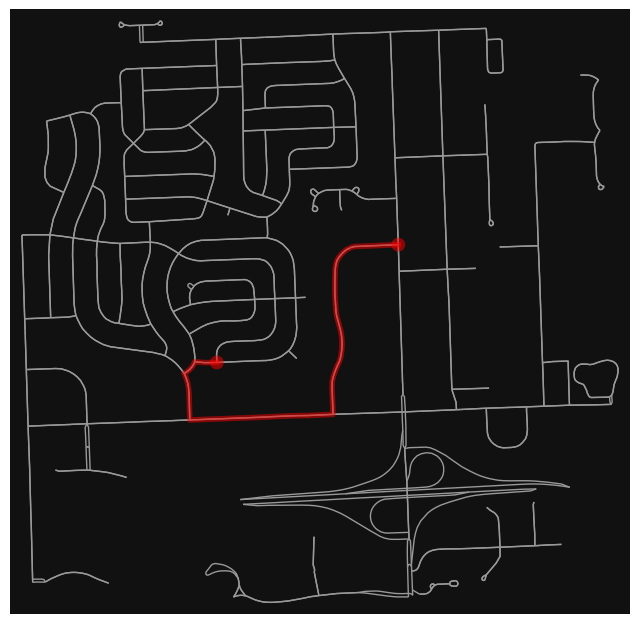

In [1]:
from functools import total_ordering
import osmnx as ox
import networkx as nx
from queue import Queue
from collections import deque
import scipy
import sklearn
from osmnx import geocode
import tkinter as tk
from tkinter import *
import math


def bfs(G, start, end): #The actual BFS algorithm
    queue = deque([start]) #uses a deque to store nodes, should be faster than a queue (optimization I made for speed)
    visited = set([start]) #stores visited nodes and puts the start node in by default
    parent = {} #stores parents of nodes, part of an optimization that allows the algorithm to not
                #store whole paths, but just nodes and use parent to trace back the path
                #Optimizations were deemed necessary after seeing runtime hit 2 minutes on an 8-mile search radius
                #it still isn't very fast, but optimizations shaved off about 10-20 seconds from that 2 minute runtime
    while queue: #while there are nodes to explore, keep exploring
        current = queue.popleft()

        if current == end: #end the loop if the end has been found
            break

        for neighbor in G.neighbors(current): #mark neighbors as visited and record their parents, then add to queue
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = current
                queue.append(neighbor)

    # reconstruct path from parents, starting from end node, then reverse list to get proper ordering of nodes
    path = []
    node = end
    while node != start:
        path.append(node)
        node = parent[node]
    path.append(start)
    path.reverse()

    return path

def validateGeocode(address): #returns coordinates if the address can be geocoded, else returns None
    try:
        point = ox.geocode(address)
        return point
    except Exception:
        return None

def pathLength(G, path): #Calculates the path length in meters via OSM edge data
    total = 0

    for i in range(len(path)-1):
        u = path[i]
        v = path[i + 1]

        edgeData = G.get_edge_data(u, v)

        length = min(d['length'] for d in edgeData.values())

        total += length
    return total

def compress_roads(roads): #removes redundant road names from multiple edges on same road
    result = []
    prev = None

    for road in roads:
        if road != prev and road != "Unnamed road":
            result.append(road)
            prev = road

    return result

def get_road_names(G, path): #gets the road names from path, cleans them with compress_roads, and returns the list of names
    roads = []

    for i in range(len(path) - 1):
        u = path[i]
        v = path[i + 1]

        edgeData = G.get_edge_data(u, v)
        edge = min(edgeData.values(), key=lambda d: d['length'])

        name = edge.get('name', 'Unnamed road')

        roads.append(name)
    cleanRoads = compress_roads(roads)
    return cleanRoads

def main():
    #input validation first
    safety = None #used to validate input, if it is none it will prompt again for start or end
                  #if it is a point it will move on
    wrongInput = "Sorry, your input was invalid, please try again" #what will be shown for invalid input
    net = '' #included in output, starts at empty string, replaced by WrongInput if user inputs an invalid address
    while safety is None:
        StartInput = input("Please Enter the location to start searching from\n"
                           "Enter in Format: <Address Number> <Street>, <City>, <State>\n"
                           "Example: 28230 Orchard Lake rd, Farmington Hills, Michigan\n"
                           "WARNING: Start and End being too far apart may cause search to be very slow\n"
                           f"{net}")
        safety = validateGeocode(StartInput)
        if safety is None: net = wrongInput
    safety = None
    net = ''
    while safety is None:
        EndInput = input("Please Enter the location to Finish Searching at\n"
                           "Enter in Format: <Address Number> <Street>, <City>, <State>\n"
                           "Example: 28230 Orchard Lake rd, Farmington Hills, Michigan\n"
                           "WARNING: Start and End being more than a few miles apart may cause search to be very slow\n"
                           f"{net}")
        safety = validateGeocode(EndInput)
        if safety is None: net = wrongInput
    start = ox.geocode(StartInput) #geocodes the start address
    lat, lon = start
    end = ox.geocode(EndInput) #geocodes the ending address
    lat2, lon2 = end

    print("Start:", start)
    print("End:", end)

    #Grabs the center latitude/longitude
    center_lat = (start[0] + end[0]) / 2
    center_lon = (start[1] + end[1]) / 2

    # rough distance in meters
    dx = (start[1] - end[1]) * 111000
    dy = (start[0] - end[0]) * 111000

    distance = math.sqrt(dx**2 + dy**2)

    # add buffer on map
    dist = int(distance * 1.3)  #dist ensures that the points will be inside the drawn map

    G = ox.graph_from_point( #draws the map with no visible node, just roads/edges
    (center_lat, center_lon),
    dist=dist,
    network_type="drive")

    #snaps the geocoded locations to actual nodes
    start_node = ox.distance.nearest_nodes(G, X=lon, Y=lat)
    end_node   = ox.distance.nearest_nodes(G, X=lon2, Y=lat2)

    #calculates the path, the length of the path, and the roads taken
    path = bfs(G, start_node, end_node)
    length = pathLength(G, path)
    roadPath = get_road_names(G, path)

    #user output
    print(f"Path length: {len(path)-1}")
    print(f"Path as node ID's is as follows: {path}")
    print(f"Path as road names is as follows: {roadPath}")
    print(f"Approximate distance: {length / 1609} miles")
    print(f"Estimated travel time assuming average total speed of 25 MPH: {((length / 1609) / 25)*60} minutes")
    print(f"Estimated travel time assuming average total speed of 45 MPH: {((length / 1609) / 45)*60} minutes")
    print(f"Estimated travel time assuming average total speed of 70 MPH: {((length / 1609) / 70)*60} minutes")

    #actually draws the path on the graph and displays it
    ox.plot_graph_route(G,
                        path,
                        node_size=0)

if __name__ == '__main__':
    main()

